In [1]:
from pathlib import Path
import requests

DATA_PATH = Path("data")
PATH = DATA_PATH / "mnist"

PATH.mkdir(parents=True, exist_ok=True)

URL = "https://github.com/pytorch/tutorials/raw/main/_static/"
FILENAME = "mnist.pkl.gz"

if not (PATH / FILENAME).exists():
        content = requests.get(URL + FILENAME).content
        (PATH / FILENAME).open("wb").write(content)

`Path` from `pathlib` is a module that provides an object-oriented interface for working with file system paths. It allows you to manipulate and interact with file paths in a more intuitive way compared to traditional string manipulation.

`requests` is a popular Python library for making HTTP requests. It provides a simple and elegant API for sending HTTP requests and handling responses, making it easier to interact with web services and APIs.

The rest of the code above is responsible for setting up the directory structure and downloading the MNIST dataset if it doesn't already exist in the specified path. It checks if the file `mnist.pkl.gz` exists in the `data/mnist` directory, and if not, it retrieves the file from the provided URL and saves it to the local filesystem.

In [2]:
import pickle
import gzip

with gzip.open((PATH / FILENAME).as_posix(), "rb") as f:
        ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding="latin-1")

C:\Users\rasno\AppData\Local\Temp\ipykernel_42992\2203444482.py:5: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding="latin-1")


import pickle
import gzip

with gzip.open((PATH / FILENAME).as_posix(), "rb") as f:
        ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding="latin-1")

`pickle` is a Python module used for serializing and deserializing Python objects. In this code, it is used to load the MNIST dataset from a compressed file. The `gzip` module is used to handle the compressed file format, allowing us to read the contents of the `.gz` file directly without needing to decompress it first.

This block of code opens the compressed file containing the MNIST dataset, reads its contents, and loads the training and validation data into the variables `x_train`, `y_train`, `x_valid`, and `y_valid`. The `encoding="latin-1"` argument is used to ensure that the data is read correctly, especially if it contains non-ASCII characters.

The `x` and `y` variables represent the input data (images) and their corresponding labels (digits) for both the training and validation sets. This data will be used later for training a neural network model to recognize handwritten digits.

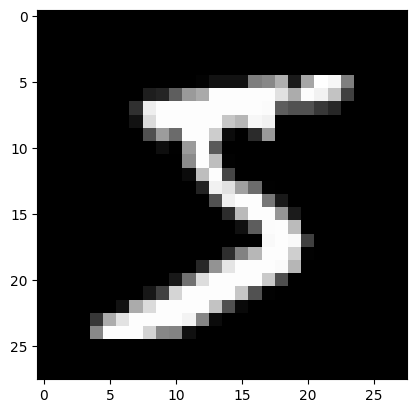

(50000, 784)


In [3]:
from matplotlib import pyplot
import numpy as np

pyplot.imshow(x_train[0].reshape((28, 28)), cmap="gray")
# ``pyplot.show()`` only if not on Colab
try:
    import google.colab
except ImportError:
    pyplot.show()
print(x_train.shape)

`numpy` and `matplotlib` are libraries commonly used for data manipulation and visualization in Python. In this code snippet, `numpy` is used to reshape the first training image from a flat array of 784 pixels back into its original 28x28 pixel format, while `matplotlib.pyplot` is used to display the image. The `imshow` function is called to visualize the image in grayscale, and `pyplot.show()` is conditionally called to display the plot if the code is not running in a Google Colab environment. Finally, the shape of the `x_train` array is printed, which indicates the number of training samples and the number of features (pixels) for each sample.

In [4]:
import torch

x_train, y_train, x_valid, y_valid = map(
    torch.tensor, (x_train, y_train, x_valid, y_valid)
)
n, c = x_train.shape
print(x_train, y_train)
print(x_train.shape)
print(y_train.min(), y_train.max())

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]]) tensor([5, 0, 4,  ..., 8, 4, 8])
torch.Size([50000, 784])
tensor(0) tensor(9)


PyTorch uses `torch.tensor` to convert the NumPy arrays into PyTorch tensors, which are the primary data structure used for building and training neural networks in PyTorch. The `map` function applies `torch.tensor` to each of the input arrays (`x_train`, `y_train`, `x_valid`, `y_valid`) to create corresponding tensors. The shape of `x_train` is printed to confirm the dimensions of the training data, and the minimum and maximum values of `y_train` are printed to verify the range of the labels.